The notebook aims to generate some insights and predictions based on the data collected from IPL matches over multiple years. The project involves two csv files, which contain all the required data.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
df=pd.read_csv("matches.csv")

df['win_by_runs'] = df['win_by_runs'].replace(0, np.nan).astype('Int64')
df['win_by_wickets'] = df['win_by_wickets'].replace(0, np.nan).astype('Int64')
df.loc[df['result'] == 'tie', 'winner'] = np.nan

Representation of column and sample values of "matches.csv" file

In [5]:
df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,05-04-17,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,<NA>,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,06-04-17,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,<NA>,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,07-04-17,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,<NA>,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,08-04-17,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,<NA>,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,08-04-17,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,<NA>,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [10]:
fd=pd.read_csv("deliveries.csv")

City with most matches

In [8]:

df['city'].value_counts().nlargest(1)

city
Mumbai    101
Name: count, dtype: int64

Representation of column and sample values of "deliveries.csv" file

In [11]:
fd.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


Total count of matches city wise

In [12]:
df['city'].value_counts()

city
Mumbai            101
Kolkata            77
Delhi              74
Bangalore          66
Hyderabad          64
Chennai            57
Jaipur             47
Chandigarh         46
Pune               38
Durban             15
Bengaluru          14
Visakhapatnam      13
Centurion          12
Ahmedabad          12
Mohali             10
Rajkot             10
Dharamsala          9
Indore              9
Johannesburg        8
Port Elizabeth      7
Abu Dhabi           7
Cape Town           7
Ranchi              7
Cuttack             7
Sharjah             6
Raipur              6
Kochi               5
Kanpur              4
Kimberley           3
Nagpur              3
East London         3
Bloemfontein        2
Name: count, dtype: int64

Team with maximum toss wins

In [13]:
df['toss_winner'].value_counts().nlargest(1)

toss_winner
Mumbai Indians    98
Name: count, dtype: int64

Team with minimum toss wins

In [14]:
df['toss_winner'].value_counts().nsmallest(1)

toss_winner
Rising Pune Supergiant    6
Name: count, dtype: int64

Teams along with the number of times they opted for batting vs balling after winning toss.

In [15]:
pd.crosstab(df.toss_decision,df.toss_winner)

toss_winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Delhi Daredevils,Gujarat Lions,Kings XI Punjab,Kochi Tuskers Kerala,Kolkata Knight Riders,Mumbai Indians,Pune Warriors,Rajasthan Royals,Rising Pune Supergiant,Rising Pune Supergiants,Royal Challengers Bangalore,Sunrisers Hyderabad
toss_decision,,,,,,,,,,,,,,,
bat,48,24,2,29,1,26,3,30,44,11,32,0,3,20,20
field,41,19,8,51,14,55,5,62,54,9,48,6,4,61,26


Checking whether the toss winner was also the match winner, grouped by teams.

In [16]:
df['toss_match_winner'] = df.apply(lambda row: 'yes' if row['toss_winner'] == row['winner'] else ('tie' if row['result'] == 'tie' else 'no'), axis=1)

result_crosstab = pd.crosstab(df['toss_winner'], df['toss_match_winner'])

total_toss_winner_matches = df['toss_winner'].value_counts()

crosstab_df = result_crosstab.reset_index()
crosstab_df['Total Matches'] = crosstab_df['toss_winner'].map(total_toss_winner_matches)

crosstab_df.columns = ['toss_winner', 'lost', 'tie', 'won', 'Total Matches']
crosstab_df = crosstab_df[['toss_winner', 'Total Matches', 'won', 'lost', 'tie']]
crosstab_df = crosstab_df.fillna(0).astype({'won': 'int64', 'lost': 'int64', 'tie': 'int64'})

crosstab_df


,toss_winner,Total Matches,won,lost,tie
0,Chennai Super Kings,89,57,31,1
1,Deccan Chargers,43,19,24,0
2,Delhi Capitals,10,6,3,1
3,Delhi Daredevils,80,35,45,0
4,Gujarat Lions,15,10,4,1
5,Kings XI Punjab,81,34,46,1
6,Kochi Tuskers Kerala,8,4,4,0
7,Kolkata Knight Riders,92,53,38,1
8,Mumbai Indians,98,55,42,1
9,Pune Warriors,20,3,17,0


Matches which resulted in a tie along with its details.

In [17]:
tie_matches = df.loc[df['result'] == 'tie', ['team1', 'team2', 'date']]
print(tie_matches.to_string(index=False))

                      team1                       team2     date
              Gujarat Lions              Mumbai Indians 29-04-17
           Rajasthan Royals       Kolkata Knight Riders 23-04-09
            Kings XI Punjab         Chennai Super Kings 21-03-10
Royal Challengers Bangalore         Sunrisers Hyderabad 07-04-13
           Delhi Daredevils Royal Challengers Bangalore 16-04-13
           Rajasthan Royals       Kolkata Knight Riders 29-04-14
           Rajasthan Royals             Kings XI Punjab 21-04-15
      Kolkata Knight Riders              Delhi Capitals 30-03-19
             Mumbai Indians         Sunrisers Hyderabad 02-05-19


Find the team name who won the match by highest runs

In [18]:
df.loc[df.win_by_runs==df.win_by_runs.max(), ['season', 'date', 'venue', 'team1', 'team2', 'winner', 'win_by_runs']]

,season,date,venue,team1,team2,winner,win_by_runs
43,2017,06-05-17,Feroz Shah Kotla,Mumbai Indians,Delhi Daredevils,Mumbai Indians,146


Find the team name who won the match by lowest runs

In [19]:
df['win_by_runs'] = df['win_by_runs']
df.loc[df.win_by_runs==df.win_by_runs.min(), ['season', 'date', 'venue', 'team1', 'team2', 'winner', 'win_by_runs']]

,season,date,venue,team1,team2,winner,win_by_runs
58,2017,21-05-17,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,Mumbai Indians,1
105,2008,21-05-08,Wankhede Stadium,Kings XI Punjab,Mumbai Indians,Kings XI Punjab,1
163,2009,17-05-09,New Wanderers Stadium,Kings XI Punjab,Deccan Chargers,Kings XI Punjab,1
344,2012,29-04-12,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Delhi Daredevils,1
350,2012,03-05-12,Subrata Roy Sahara Stadium,Mumbai Indians,Pune Warriors,Mumbai Indians,1
518,2015,09-04-15,"MA Chidambaram Stadium, Chepauk",Chennai Super Kings,Delhi Daredevils,Chennai Super Kings,1
598,2016,27-04-16,Feroz Shah Kotla,Gujarat Lions,Delhi Daredevils,Gujarat Lions,1
614,2016,09-05-16,"Punjab Cricket Association IS Bindra Stadium, ...",Royal Challengers Bangalore,Kings XI Punjab,Royal Challengers Bangalore,1
734,2019,21-04-19,M. Chinnaswamy Stadium,Royal Challengers Bangalore,Chennai Super Kings,Royal Challengers Bangalore,1
755,2019,12-05-19,Rajiv Gandhi Intl. Cricket Stadium,Mumbai Indians,Chennai Super Kings,Mumbai Indians,1


Find the player who was awarded as player of the match maximum times.

In [20]:
df.player_of_match.value_counts().nlargest(1)

player_of_match
CH Gayle    21
Name: count, dtype: int64

Find the umpires who did umpiring maximum times

In [21]:
for a in ['umpire1','umpire2','umpire3']:
    print("For "+a+" maximum is : ")
    print(df[a].value_counts().idxmax())

For umpire1 maximum is : 
HDPK Dharmasena
For umpire2 maximum is : 
S Ravi
For umpire3 maximum is : 
Nitin Menon


Find the total matches played in each season

In [22]:
pd.crosstab(df.season,0)

col_0,0
season,
2008,58
2009,57
2010,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


Find the total runs in each season

In [23]:
match_detail=df[['id', 'season']].merge(fd, left_on='id', right_on='match_id', how='left')

match_detail.groupby(['season'])['total_runs'].sum().reset_index()

,season,total_runs
0,2008,17937
1,2009,16353
2,2010,18883
3,2011,21154
4,2012,22453
5,2013,22602
6,2014,18931
7,2015,18353
8,2016,18862
9,2017,18786


No. of tosses won by each team

In [24]:
df['toss_winner'].value_counts()

toss_winner
Mumbai Indians                 98
Kolkata Knight Riders          92
Chennai Super Kings            89
Kings XI Punjab                81
Royal Challengers Bangalore    81
Delhi Daredevils               80
Rajasthan Royals               80
Sunrisers Hyderabad            46
Deccan Chargers                43
Pune Warriors                  20
Gujarat Lions                  15
Delhi Capitals                 10
Kochi Tuskers Kerala            8
Rising Pune Supergiants         7
Rising Pune Supergiant          6
Name: count, dtype: int64

Visualize the toss decision across seasons

<Axes: xlabel='season', ylabel='count'>

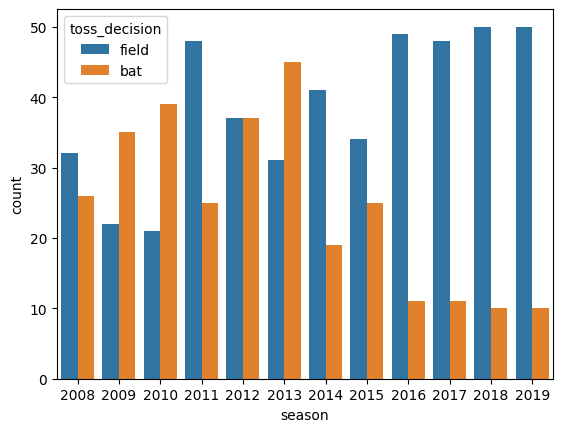

In [25]:
sns.countplot(data=df ,x=df.season,hue=df['toss_decision'])

Find the dismissal kind and visualize using best fit graph.

<Axes: xlabel='count', ylabel='dismissal_kind'>

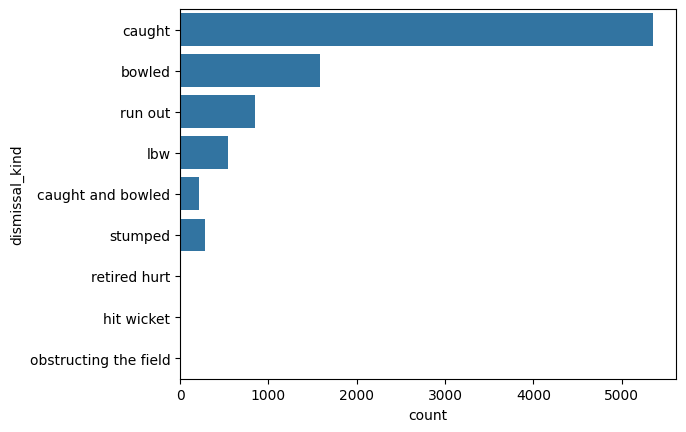

In [26]:
fd['dismissal_kind'].unique()
sns.countplot(data=fd,y=fd.dismissal_kind)

Visualising the top 10 run scorers in IPL over the years.

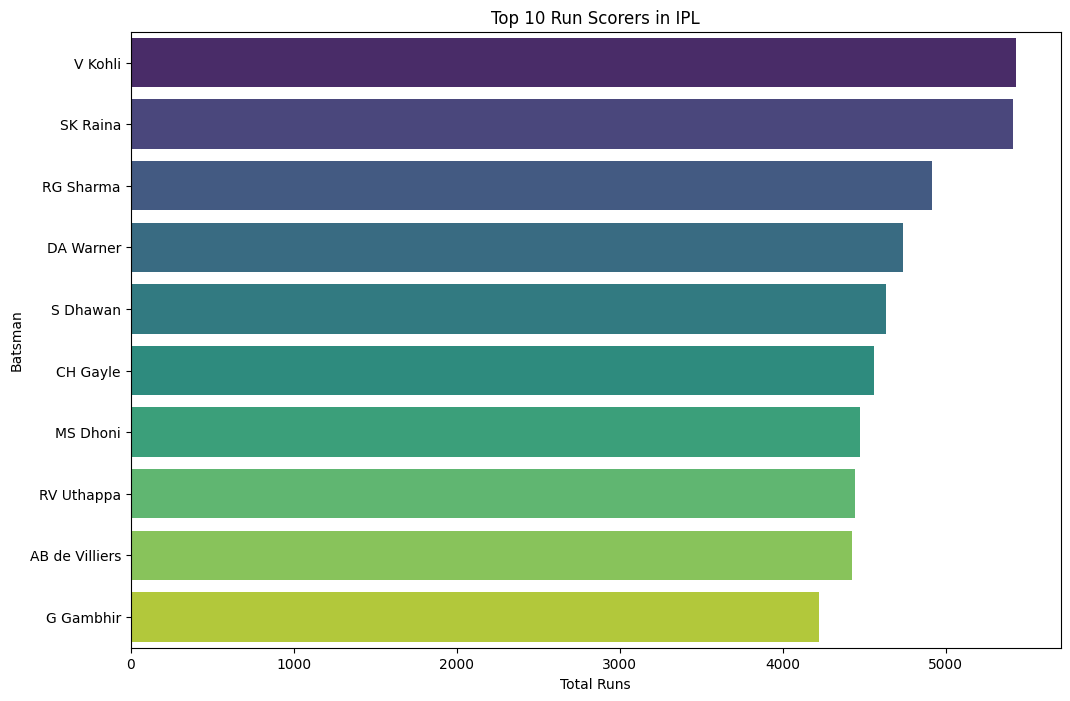

In [27]:
totruns =fd.groupby("batsman")["batsman_runs"].sum().sort_values(ascending=False).reset_index()
top_10_batsmen = totruns.head(10)
plt.figure(figsize=(12, 8))
sns.barplot(data=top_10_batsmen, x='batsman_runs', y='batsman', hue='batsman', palette='viridis', dodge=False)
plt.title('Top 10 Run Scorers in IPL')
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.legend([], [], frameon=False)
plt.show()

Visualising to represent the players who have won more than 3 Man of the Match titles.

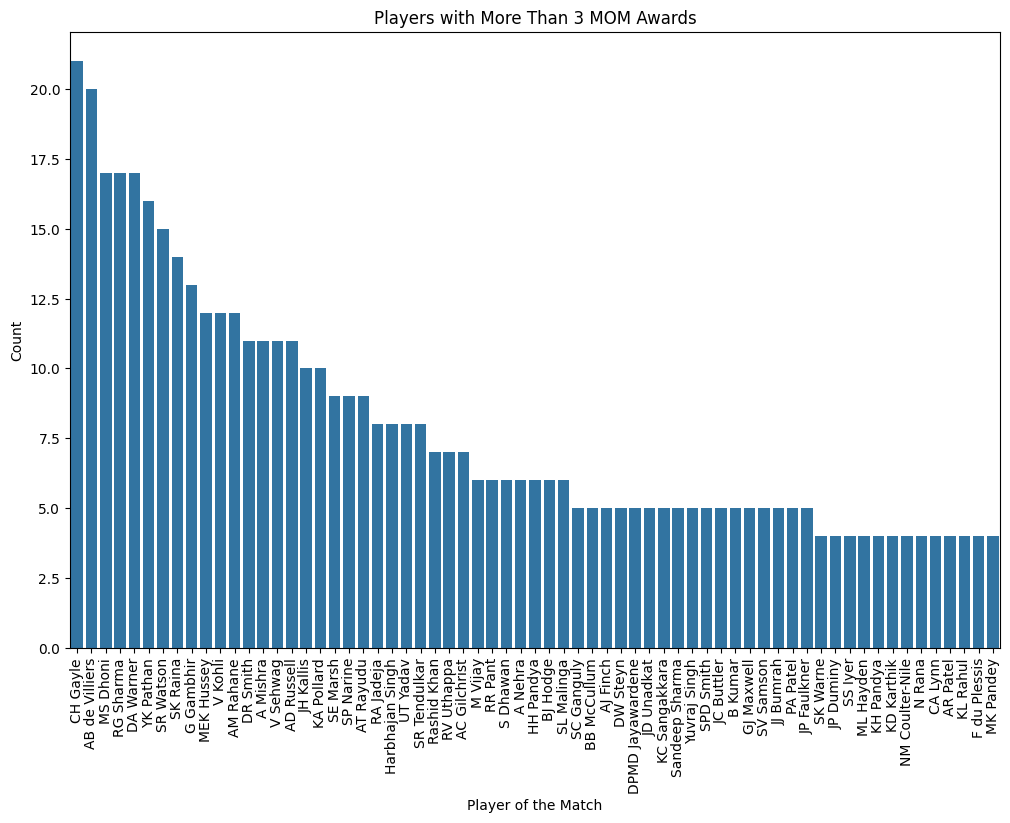

In [28]:
mom_counts = df['player_of_match'].value_counts()
top_mom_winners = mom_counts[mom_counts > 3].index
filtered_df = df[df['player_of_match'].isin(top_mom_winners)]

plt.figure(figsize=(12, 8))
sns.countplot(data=filtered_df, x='player_of_match', order=top_mom_winners)
plt.xticks(rotation=90)

plt.title('Players with More Than 3 MOM Awards')
plt.xlabel('Player of the Match')
plt.ylabel('Count')
plt.show()

Correlation Matrix - Shows the correlation between two variables

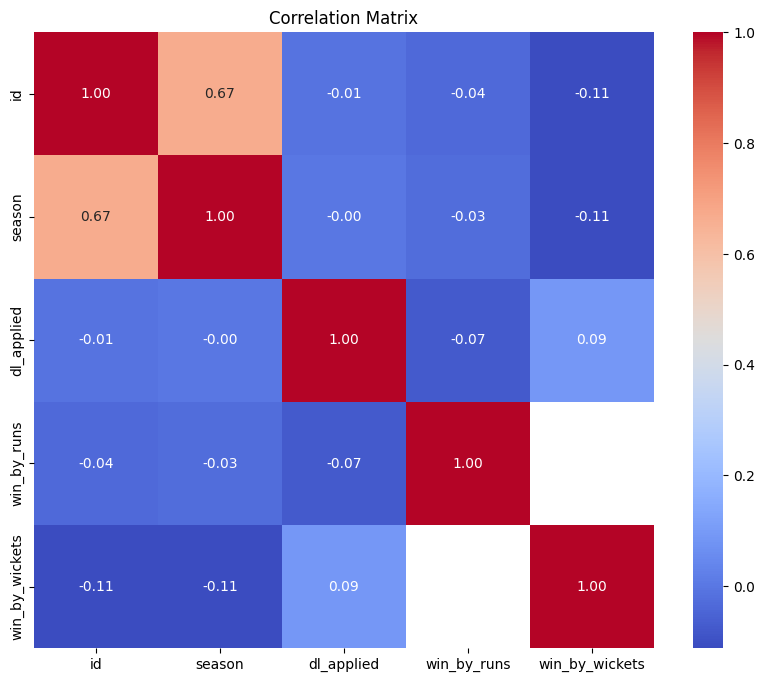

In [29]:
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

*The following cells require certain libraries to run GUI. The details of the same have been given in the readme file of GitHub repository.*

*UI component for the all the following codes have been added in separate files alongside this file in the Git Repository.*

---
This model analyses the entire data and use our formula of choosing the player of the match and tries to predict the player of the match for any IPL match, the actual player of the match is also printed, representing the accuracy of this model.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import ipywidgets as widgets
from IPython.display import display

data = pd.merge(fd, df[['id', 'player_of_match']], left_on='match_id', right_on='id')

match_data = data[['match_id', 'player_of_match', 'batsman', 'bowler', 'batsman_runs', 'total_runs', 'player_dismissed', 'dismissal_kind']]
batsman_stats = match_data.groupby(['match_id', 'batsman'])['batsman_runs'].agg(['sum', 'count']).reset_index()
batsman_stats['strike_rate'] = (batsman_stats['sum'] / batsman_stats['count']) * 100
batsman_stats.rename(columns={'sum': 'total_runs', 'count': 'balls_faced'}, inplace=True)

bowler_stats = match_data.groupby(['match_id', 'bowler'])['total_runs'].agg(['sum', 'count']).reset_index()
bowler_stats['wickets'] = match_data[match_data['player_dismissed'].notnull()].groupby(['match_id', 'bowler']).size().reset_index(name='wickets')['wickets']
bowler_stats['economy_rate'] = (bowler_stats['sum'] / (bowler_stats['count'] / 6))
bowler_stats.rename(columns={'sum': 'runs_conceded', 'count': 'balls_bowled'}, inplace=True)

player_stats = pd.merge(batsman_stats, bowler_stats, left_on=['match_id', 'batsman'], right_on=['match_id', 'bowler'], how='outer')
player_stats = pd.merge(player_stats, df[['id', 'player_of_match']], left_on='match_id', right_on='id', how='left')
player_stats = player_stats.fillna(0)
player_stats['is_player_of_match'] = player_stats.apply(lambda row: 1 if row['batsman'] == row['player_of_match'] else 0, axis=1)
player_stats = player_stats.drop(columns=['batsman', 'bowler', 'player_of_match', 'id'])

X = player_stats[['strike_rate', 'economy_rate', 'wickets', 'total_runs', 'balls_faced', 'runs_conceded', 'balls_bowled']]
y = player_stats['is_player_of_match']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the Random Forest Classifier model: {accuracy:.2f}")
def check_match_accuracy(match_id):
    match_data = data[data['match_id'] == match_id]
    if match_data.empty:
        return f"No data available for match ID {match_id}"

    batsman_stats = match_data.groupby(['match_id', 'batsman'])['batsman_runs'].agg(['sum', 'count']).reset_index()
    batsman_stats['strike_rate'] = (batsman_stats['sum'] / batsman_stats['count']) * 100
    batsman_stats.rename(columns={'sum': 'total_runs', 'count': 'balls_faced'}, inplace=True)

    bowler_stats = match_data.groupby(['match_id', 'bowler'])['total_runs'].agg(['sum', 'count']).reset_index()
    bowler_stats['wickets'] = match_data[match_data['player_dismissed'].notnull()].groupby(['match_id', 'bowler']).size().reset_index(name='wickets')['wickets']
    bowler_stats['economy_rate'] = (bowler_stats['sum'] / (bowler_stats['count'] / 6))
    bowler_stats.rename(columns={'sum': 'runs_conceded', 'count': 'balls_bowled'}, inplace=True)

    match_stats = pd.merge(batsman_stats, bowler_stats, left_on=['match_id', 'batsman'], right_on=['match_id', 'bowler'], how='outer').fillna(0)

    X_match = match_stats[['strike_rate', 'economy_rate', 'wickets', 'total_runs', 'balls_faced', 'runs_conceded', 'balls_bowled']]
    y_match_pred = model.predict(X_match)

    match_stats['predicted_is_player_of_match'] = y_match_pred
    actual_player_of_match = df[df['id'] == match_id]['player_of_match'].values[0]
    predicted_players = match_stats[match_stats['predicted_is_player_of_match'] == 1]['batsman'].values

    if actual_player_of_match in predicted_players:
        result = {
            'match_id': match_id,
            'actual_player': actual_player_of_match,
            'predicted_players': predicted_players.tolist()
        }
        return result
    else:
        return f"No predicted player of the match for match ID {match_id}. This could be due to insufficient data or the model's inability to confidently predict a player of the match for this particular match."


def show_ui():
    match_id_input = widgets.Text(
        value='',
        placeholder='Enter match ID',
        description='Match ID:',
        disabled=False
    )
    result_output = widgets.Output()
    def on_button_click(b):
        with result_output:
            result_output.clear_output()
            match_id = match_id_input.value
            try:
                match_id = int(match_id)
                result = check_match_accuracy(match_id)
                if isinstance(result, dict):
                    print(f"Match ID: {result['match_id']}")
                    print(f"Actual Player of the Match: {result['actual_player']}")
                    print("Predicted Players of the Match:")
                    for player in result['predicted_players']:
                        print(player)
                else:
                    print(result)
            except ValueError:
                print("Please enter a valid match ID.")

    check_button = widgets.Button(
        description='Check Accuracy',
        disabled=False,
        button_style='',
        tooltip='Click to check accuracy',
        icon='check'
    )
    check_button.on_click(on_button_click)

    display(match_id_input, check_button, result_output)

show_ui()


Accuracy of the Random Forest Classifier model: 0.96


Text(value='', description='Match ID:', placeholder='Enter match ID')

Button(description='Check Accuracy', icon='check', style=ButtonStyle(), tooltip='Click to check accuracy')

Output()

This model has analysed the trends of the data taken and gives a win probability based on the teams playing, the venue and the target.



In [31]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import ipywidgets as widgets
from IPython.display import display

deliveries_df = pd.read_csv('deliveries.csv')
matches_df = pd.read_csv('matches.csv')

df = matches_df[['id', 'venue', 'team1', 'team2', 'winner']]

first_innings_scores = deliveries_df[deliveries_df['inning'] == 1].groupby('match_id')['total_runs'].sum().reset_index()
first_innings_scores.rename(columns={'total_runs': 'first_innings_score'}, inplace=True)

df = pd.merge(df, first_innings_scores, left_on='id', right_on='match_id', how='left')

df['match_outcome'] = df.apply(lambda row: 1 if row['winner'] == row['team1'] else 0, axis=1)

df = df.dropna(subset=['match_outcome'])

df = df[['venue', 'team1', 'team2', 'first_innings_score', 'match_outcome']]

label_encoder_venue = LabelEncoder()
df['venue_encoded'] = label_encoder_venue.fit_transform(df['venue'])

label_encoder_team = LabelEncoder()
df['team1_encoded'] = label_encoder_team.fit_transform(df['team1'])
df['team2_encoded'] = label_encoder_team.fit_transform(df['team2'])

X = df[['venue_encoded', 'team1_encoded', 'team2_encoded', 'first_innings_score']]
y = df['match_outcome']

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

def predict_win_probability(first_innings_score, venue, team1, team2):
    venue_encoded = label_encoder_venue.transform([venue])[0]
    team1_encoded = label_encoder_team.transform([team1])[0]
    team2_encoded = label_encoder_team.transform([team2])[0]

    input_data = np.array([[venue_encoded, team1_encoded, team2_encoded, first_innings_score]])
    win_probability = best_rf.predict_proba(input_data)[:, 1][0]
    return win_probability

def on_predict_button_clicked(b):
    venue = venue_dropdown.value
    team1 = team1_dropdown.value
    team2 = team2_dropdown.value
    first_innings_score = int(first_innings_score_input.value)

    win_probability = predict_win_probability(first_innings_score, venue, team1, team2)
    result_label.value = f"Win Probability for {team1}: {win_probability:.2f}"

venue_dropdown = widgets.Dropdown(
    options=sorted(df['venue'].unique()),
    description='Venue:',
)

team1_dropdown = widgets.Dropdown(
    options=sorted(df['team1'].unique()),
    description='Team 1:',
)

team2_dropdown = widgets.Dropdown(
    options=sorted(df['team2'].unique()),
    description='Team 2:',
)

first_innings_score_input = widgets.IntText(
    description='First Innings Score:'
)

predict_button = widgets.Button(
    description='Predict Win Probability',
)

result_label = widgets.Label(value="")

predict_button.on_click(on_predict_button_clicked)

display(venue_dropdown, team1_dropdown, team2_dropdown, first_innings_score_input, predict_button, result_label)


Dropdown(description='Venue:', options=('ACA-VDCA Stadium', 'Barabati Stadium', 'Brabourne Stadium', 'Buffalo …

Dropdown(description='Team 1:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Da…

Dropdown(description='Team 2:', options=('Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Da…

IntText(value=0, description='First Innings Score:')

Button(description='Predict Win Probability', style=ButtonStyle())

Label(value='')

Predicts whether a particular pitch is a batting or a bowling-favoured pitch. This classification is based on comparing the average score across all the stadiums with the average score across the particular stadium.

In [32]:
import ipywidgets as widgets
from IPython.display import display

df = pd.read_csv('matches.csv')
fd = pd.read_csv('deliveries.csv')

data = pd.merge(fd, df[['id', 'venue']], left_on='match_id', right_on='id')

venue_stats = data.groupby(['venue', 'inning']).agg({
    'total_runs': 'sum',
    'player_dismissed': 'count'
}).reset_index()

first_innings_stats = venue_stats[venue_stats['inning'] == 1]
second_innings_stats = venue_stats[venue_stats['inning'] == 2]

combined_stats = pd.merge(first_innings_stats, second_innings_stats, on='venue', suffixes=('_1st', '_2nd'))

combined_stats['batting_friendly_score'] = (combined_stats['total_runs_1st'] + combined_stats['total_runs_2nd']) / 2
combined_stats['bowling_friendly_score'] = (combined_stats['player_dismissed_1st'] + combined_stats['player_dismissed_2nd']) / 2

def pitch_type(row):
    if row['batting_friendly_score'] > row['bowling_friendly_score']:
        return 'Batting Friendly'
    else:
        return 'Bowling Friendly'

combined_stats['pitch_type'] = combined_stats.apply(pitch_type, axis=1)

def get_pitch_type(venue):
    result = combined_stats[combined_stats['venue'] == venue]
    if not result.empty:
        return result.iloc[0]['pitch_type']
    else:
        return 'Stadium not found in the dataset'

def show_ui():
    venue_dropdown = widgets.Dropdown(
        options=combined_stats['venue'].unique(),
        description='Stadium:',
    )

    result_label = widgets.Label(value="")

    def on_button_click(b):
        venue = venue_dropdown.value
        pitch_type = get_pitch_type(venue)
        result_label.value = f"Pitch Type at {venue}: {pitch_type}"

    check_button = widgets.Button(
        description='Check Pitch Type',
        disabled=False,
        button_style='',
        tooltip='Click to check pitch type',
        icon='check'
    )
    check_button.on_click(on_button_click)

    display(venue_dropdown, check_button, result_label)

show_ui()


Dropdown(description='Stadium:', options=('ACA-VDCA Stadium', 'Barabati Stadium', 'Brabourne Stadium', 'Buffal…

Button(description='Check Pitch Type', icon='check', style=ButtonStyle(), tooltip='Click to check pitch type')

Label(value='')